# Poisson Solver Testing - Structured Nonuniform Grids

## Grids Tested

**Angular grids** (fixed across all radii, shared angular mesh):

- **Uniform:**  
  Angles: $\theta_j = \frac{2\pi j}{N}, \qquad j = 0,\dots,N-1.$  
  Parameters: none (pure equispaced grid).

- **Fibonacci (Golden Ratio):**  
  Angles: $\theta_j = 2\pi \big( (j \phi) \bmod 1 \big), \qquad j = 0,\dots,N-1.$  
  Parameters: $\phi = \frac{\sqrt{5}-1}{2} \approx 0.6180.$

- **Multi-Pole:**  
  Angles: $\xi_j = \frac{2\pi}{N}\left(j + \tfrac{1}{2}\right), \quad \theta_j = \big(\xi_j + \sum_m a_m \sin(p_m \xi_j)\big) \bmod 2\pi.$  
  Parameters: poles $p_m$ and amplitudes $a_m$ (default $p = (2, 4)$, $a = (0.06, 0.03)$).

- **Warped harmonic:**  
  Angles: $\xi_j = \frac{2\pi}{N}\left(j + \tfrac{1}{2}\right), \quad \theta_j = \xi_j + \epsilon_1 \sin(\xi_j) + \epsilon_2 \cos(2\xi_j + 0.5) \pmod{2\pi}.$  
  Parameters: $\epsilon_1 = 0.08$, $\epsilon_2 = -0.04$.

- **Chebyshev angular:**  
  Angles: $\xi_j = \frac{2\pi}{N}\left(j + \tfrac{1}{2}\right), \quad \theta_j = \xi_j - \alpha \sin(2\xi_j) \pmod{2\pi}.$  
  Parameters: $\alpha = 0.18$.


## Method Suite

Three solvers:

- **FFT** (uniform grid only): standard equispaced FFT, exact and fastest.
- **NUDFT**: direct nonuniform DFT solved via regularized least-squares 
- **NUFFT**: fast nonuniform transform via FINUFFT on the structured meshes, with Fourier coefficients recovered by an **unsquared PCGLS** (Pipe & Menon–style) conjugate-gradient solver.

We use the unsquared PCGLS NUFFT path rather than the Toeplitz/Block-CG normal-equations solver because the structured grids can have larger effective condition numbers; PCGLS avoids squaring the spectrum of the angular operator while still converging efficiently on these meshes.

In [7]:
import os, sys
import pandas as pd
# Main project root
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    set_global_config,
    get_global_config,
    render_accuracy,
    render_runtime,
    render_table2_accuracy,
    render_table2_runtime,
    plot_accuracy_table1,
    plot_runtime_table1,
    plot_accuracy_table2,
    plot_runtime_table2,
    plot_accuracy_comparison,
    plot_runtime_comparison
)


# Setup & Configurable Parameters

In [8]:
# =============================================================================
# Domain & Solver Parameters
# =============================================================================
R = 1.0                     # Disk radius
RAD_UNIF = 1                # 1: Uniform radial grid
RADIAL_MAPPING = None       # Non-uniform radial mapping if RAD_UNIF == 0
QUAD_RULE = 1               # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1               # 1: Dirichlet, 2: Neumann


# Solver Tolerances & Regularization (Lambda)
TOL_NUFFT = 1e-10           # CG residual tolerance for NUFFT
MAXITER_NUFFT = 100         # Maximum CG iterations (50-100 is optimal)
EPS_FINUFFT = 1e-12         # FINUFFT kernel precision (optimal W=10 width)
REG_PARAM = 1e-20           # Regularization parameter



# =============================================================================
# Problem Selection
# =============================================================================
PROBLEM_TYPE = 0            # 0: Borges & Daripa Problem 1, 2: Problem 2
CUSTOM_PROBLEM = None
# Apply global configuration
set_global_config(
    R=R,
    rad_unif=RAD_UNIF,
    radial_mapping=RADIAL_MAPPING,
    tol_nufft=TOL_NUFFT,
    maxiter_nufft=MAXITER_NUFFT,
    eps_finufft=EPS_FINUFFT,
    reg_param=REG_PARAM,
    quad_rule=QUAD_RULE,
    BC_choice=BC_CHOICE,
    problem_type=PROBLEM_TYPE,
    custom_problem=CUSTOM_PROBLEM,
)


# =============================================================================
# Grid Sweep Resolutions
# =============================================================================


N_vals_p1 = [32, 64, 128, 256, 512]
M_vals_p1 = [32, 64, 128, 256, 512]
N_fixed_p1 = 128


N_vals_c = [32, 64, 128, 256, 512]
M_vals_c = [32, 64, 128, 256, 512]
N_fixed_c = 128
M_fixed_c = 128


MUTE_OUTPUT = True

# Run Problems

In [9]:
# =============================================================================
# Problem 1 method suite: Uniform + Chebyshev angular
# =============================================================================
METHODS_p1 = [
    dict(
        name="Unif-FFT",
        label="Uniform / FFT",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=2,
        use_nudft=None,
    ),
    dict(
        name="Fixed-chebyshev-NUDFT",
        label="Fixed Chebyshev / NUDFT",
        azu_unif=1,
        mesh_kind="chebyshev",
        solver_azu_unif=1,
        use_nudft=True,
    ),
    dict(
        name="Fixed-chebyshev-NUFFT",
        label="Fixed Chebyshev / NUFFT",
        azu_unif=1,
        mesh_kind="chebyshev",
        solver_azu_unif=1,
        use_nudft=False,
    ),
]


# =============================================================================
# Comparison suite: Uniform + 4 structured grids
# =============================================================================
METHODS_COMP = [
    # Uniform reference
    dict(
        name="Unif-FFT",
        label="Uniform / FFT",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=2,
        use_nudft=None,
    ),
    dict(
        name="Unif-NUDFT",
        label="Uniform / NUDFT",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        use_nudft=True,
    ),
    dict(
        name="Unif-NUFFT",
        label="Uniform / NUFFT",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        use_nudft=False,
    ),
]

STRUCTURED_KINDS = [
    ("multipole",  "Multi-Pole"),
    ("fibonacci",  "Fibonacci (Golden Ratio)"),
    ("warped",     "Harmonic Warped"),
    ("chebyshev",  "Chebyshev Angular"),
]

for kind_id, kind_name in STRUCTURED_KINDS:
    METHODS_COMP += [
        dict(
            name=f"Fixed-{kind_id}-NUDFT",
            label=f"Fixed {kind_name} / NUDFT",
            azu_unif=1,
            mesh_kind=kind_id,
            solver_azu_unif=1,
            use_nudft=True,
        ),
        dict(
            name=f"Fixed-{kind_id}-NUFFT",
            label=f"Fixed {kind_name} / NUFFT",
            azu_unif=1,
            mesh_kind=kind_id,
            solver_azu_unif=1,
            use_nudft=False,
        ),
    ]


# =============================================================================
# Runs: Problem 1 and structured comparison sweeps
# =============================================================================
print("\nRunning Problem 1, Table 1: N–M resolution sweep "
      "(fixed Chebyshev angular grid)...")

df_p1_t1 = run_tests_pipeline(
    N_vals_p1, M_vals_p1,
    fixed_other=None,
    methods=METHODS_p1,
    test_type="P1_Table1",
    mute=MUTE_OUTPUT,
)

print(f"\nRunning Problem 1, Table 2: boundary-condition and quadrature sweep "
      f"(fixed N={N_fixed_p1}; fixed Chebyshev angular grid)...")

df_p1_t2 = run_tests_pipeline(
    None, M_vals_p1,
    fixed_other=N_fixed_p1,
    methods=METHODS_p1,
    test_type="P1_Table2",
    mute=MUTE_OUTPUT,
)

print("\nRunning structured nonuniform angular-grid accuracy comparisons...")

print(f"  • Varying angular resolution N with fixed radial resolution M={M_fixed_c}")
df_cN = run_tests_pipeline(
    N_vals_c, None,
    fixed_other=M_fixed_c,
    methods=METHODS_COMP,
    test_type="Accuracy_VaryN",
    mute=MUTE_OUTPUT,
)

print(f"  • Varying radial resolution M with fixed angular resolution N={N_fixed_c}")
df_cM = run_tests_pipeline(
    None, M_vals_c,
    fixed_other=N_fixed_c,
    methods=METHODS_COMP,
    test_type="Accuracy_VaryM",
    mute=MUTE_OUTPUT,
)

print("Benchmark runs complete.")


Running Problem 1, Table 1: N–M resolution sweep (fixed Chebyshev angular grid)...


Pipeline (P1_Table1): 100%|██████████| 3/3 [00:18<00:00,  6.01s/it, method=Fixed-chebyshev-NUFFT]



Running Problem 1, Table 2: boundary-condition and quadrature sweep (fixed N=128; fixed Chebyshev angular grid)...


Pipeline (P1_Table2): 100%|██████████| 3/3 [00:07<00:00,  2.49s/it, method=Fixed-chebyshev-NUFFT]



Running structured nonuniform angular-grid accuracy comparisons...
  • Varying angular resolution N with fixed radial resolution M=128


Pipeline (Accuracy_VaryN): 100%|██████████| 11/11 [00:14<00:00,  1.35s/it, method=Fixed-chebyshev-NUFFT]


  • Varying radial resolution M with fixed angular resolution N=128


Pipeline (Accuracy_VaryM): 100%|██████████| 11/11 [00:22<00:00,  2.03s/it, method=Fixed-chebyshev-NUFFT]

Benchmark runs complete.


# Accuracy across different Meshes


Structured Nonuniform Angular-Grid Comparison: Relative L2 Error vs. N
Varying angular resolution N; fixed radial resolution M=128
Meshes: uniform, multipole, Fibonacci, warped, and Chebyshev

Accuracy Comparison (Fixed M=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed Chebyshev Angular / NUDFT,Fixed Fibonacci (Golden Ratio) / NUDFT,Fixed Harmonic Warped / NUDFT,Fixed Multi-Pole / NUDFT,Fixed Chebyshev Angular / NUFFT,Fixed Fibonacci (Golden Ratio) / NUFFT,Fixed Harmonic Warped / NUFFT,Fixed Multi-Pole / NUFFT
N,,,,,,,,,,,
32,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.54e-07,6.55e-07,6.55e-07,6.55e-07,6.54e-07,6.55e-07,6.55e-07
64,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.56e-07,6.55e-07,6.55e-07,6.55e-07
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07
256,6.55e-07,6.55e-07,6.55e-07,1.55e-03,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07
512,6.55e-07,6.55e-07,6.55e-07,1.08e-02,6.55e-07,9.20e-05,4.15e-06,6.55e-07,6.55e-07,6.55e-07,6.55e-07


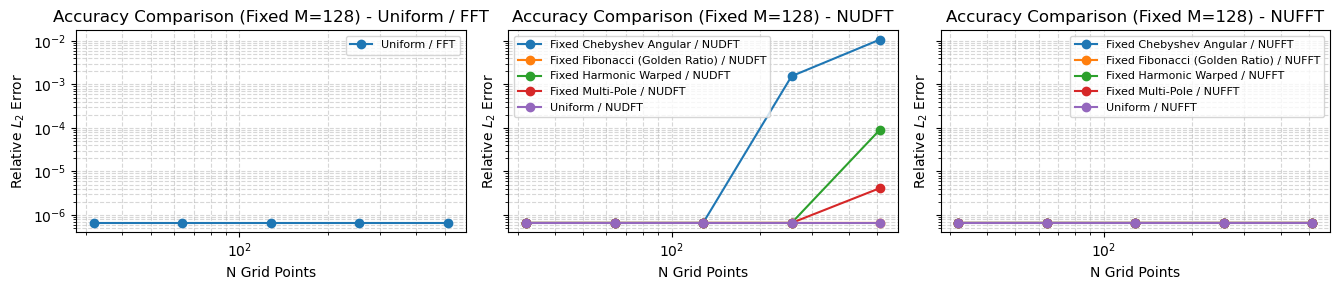


Structured Nonuniform Angular-Grid Comparison: Relative L2 Error vs. M
Varying radial resolution M; fixed angular resolution N=128
Meshes: uniform, multipole, Fibonacci, warped, and Chebyshev

Accuracy Comparison (Fixed N=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed Chebyshev Angular / NUDFT,Fixed Fibonacci (Golden Ratio) / NUDFT,Fixed Harmonic Warped / NUDFT,Fixed Multi-Pole / NUDFT,Fixed Chebyshev Angular / NUFFT,Fixed Fibonacci (Golden Ratio) / NUFFT,Fixed Harmonic Warped / NUFFT,Fixed Multi-Pole / NUFFT
M,,,,,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.55e-07
256,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.62e-07
512,4.04e-08,4.04e-08,4.04e-08,4.05e-08,4.04e-08,4.04e-08,4.04e-08,4.04e-08,4.04e-08,4.04e-08,4.04e-08


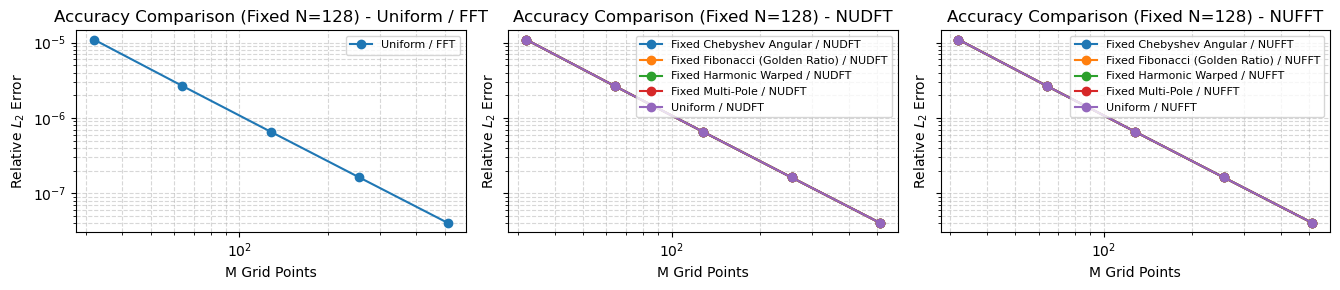

In [10]:
print("\nStructured Nonuniform Angular-Grid Comparison: Relative L2 Error vs. N")
print(f"Varying angular resolution N; fixed radial resolution M={M_fixed_c}")
print("Meshes: uniform, multipole, Fibonacci, warped, and Chebyshev")
render_accuracy(
    df_cN,
    index_col="N",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)
plot_accuracy_comparison(
    df_cN,
    index_col="N",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)


print("\nStructured Nonuniform Angular-Grid Comparison: Relative L2 Error vs. M")
print(f"Varying radial resolution M; fixed angular resolution N={N_fixed_c}")
print("Meshes: uniform, multipole, Fibonacci, warped, and Chebyshev")
render_accuracy(
    df_cM,
    index_col="M",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)
plot_accuracy_comparison(
    df_cM,
    index_col="M",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)

# Accuracy for Chebyshev grid


Problem 1 — Table 1: Relative L2 error over angular and radial resolutions
Methods: uniform FFT and fixed Chebyshev NUDFT/NUFFT

Problem 1 — Table 1 Accuracy


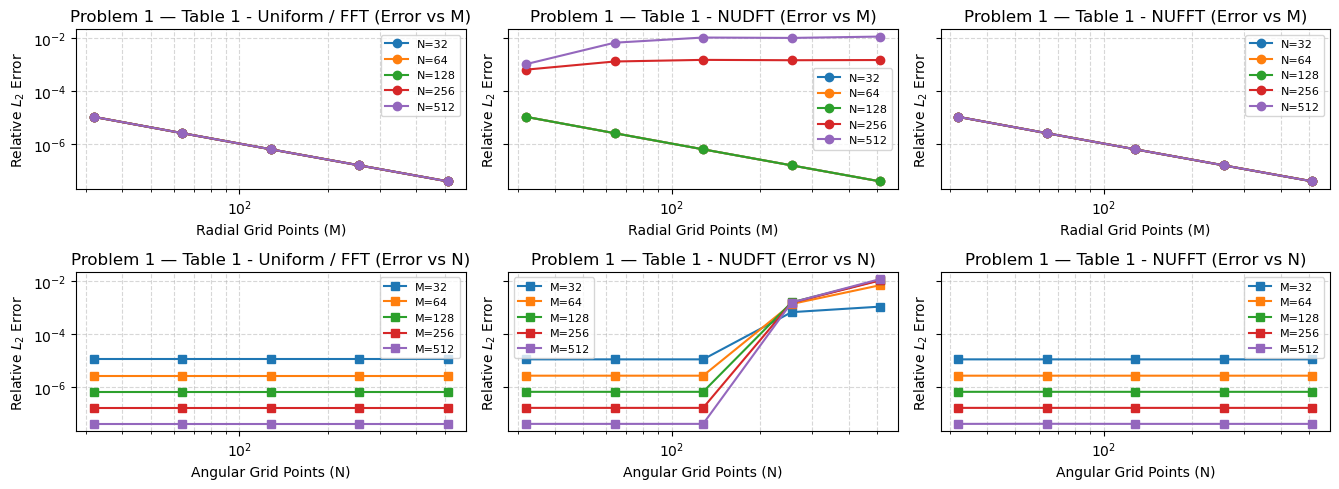


Problem 1 — Table 2: Relative L2 error by quadrature rule and boundary condition (N=128)
Methods: uniform FFT and fixed Chebyshev NUDFT/NUFFT

Problem 1 — Table 2 (Fixed N=128) Accuracy


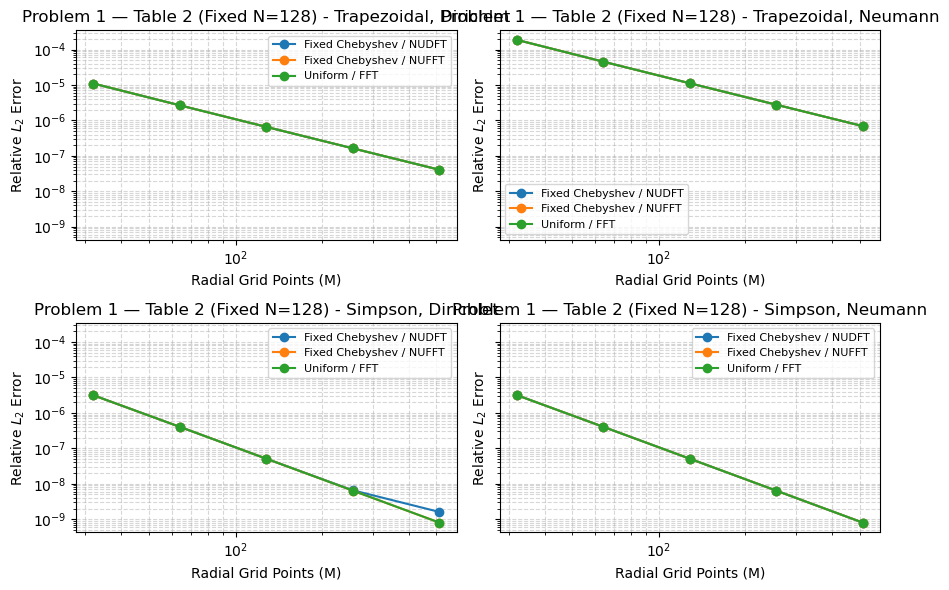

In [11]:
print("\nProblem 1 — Table 1: Relative L2 error over angular and radial resolutions")
print("Methods: uniform FFT and fixed Chebyshev NUDFT/NUFFT")
render_accuracy(
    df_p1_t1,
    index_col="N",
    columns_col=["label", "M"],
    title_prefix="Problem 1 — Table 1"
)
plot_accuracy_table1(df_p1_t1, title_prefix="Problem 1 — Table 1")


print(f"\nProblem 1 — Table 2: Relative L2 error by quadrature rule and boundary condition (N={N_fixed_p1})")
print("Methods: uniform FFT and fixed Chebyshev NUDFT/NUFFT")
render_table2_accuracy(
    df_p1_t2,
    title_prefix=f"Problem 1 — Table 2 (Fixed N={N_fixed_p1})"
)
plot_accuracy_table2(
    df_p1_t2,
    title_prefix=f"Problem 1 — Table 2 (Fixed N={N_fixed_p1})"
)

# Runtimes


Problem 1 — Table 1: Runtime over angular and radial resolutions
Methods: uniform FFT and fixed Chebyshev NUDFT/NUFFT

Problem 1 — Table 1 Runtime (s)


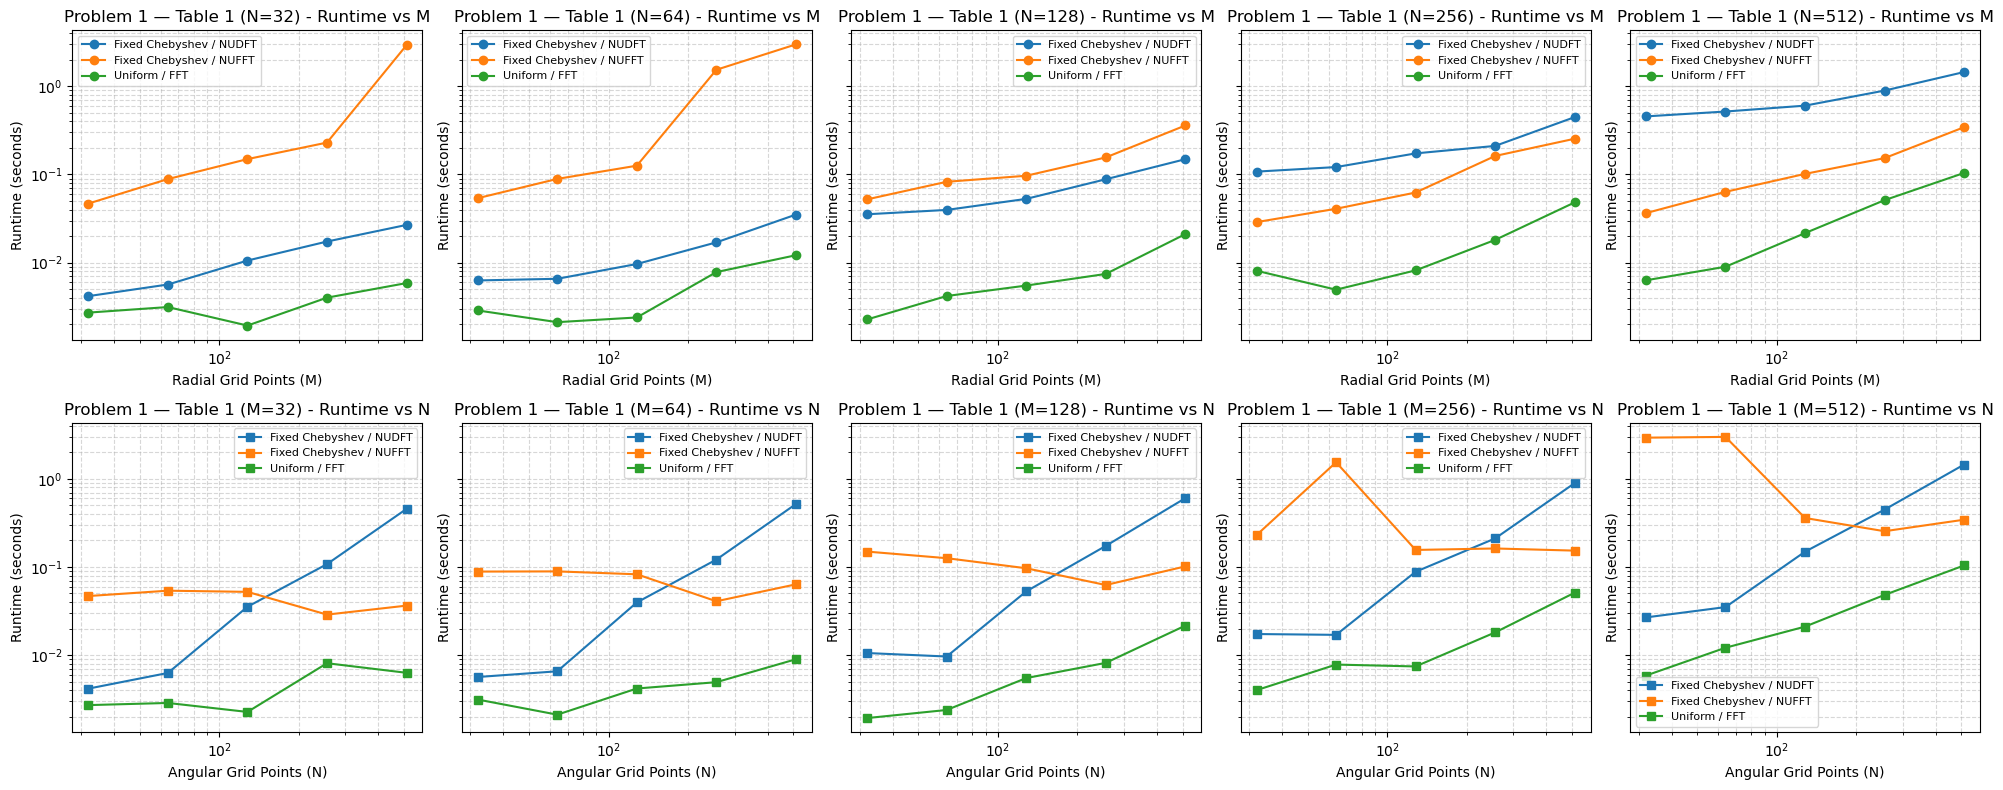


Problem 1 — Table 2: Runtime by quadrature rule and boundary condition (N=128)
Methods: uniform FFT and fixed Chebyshev NUDFT/NUFFT

Problem 1 — Table 2 (Fixed N=128) Runtime (s)


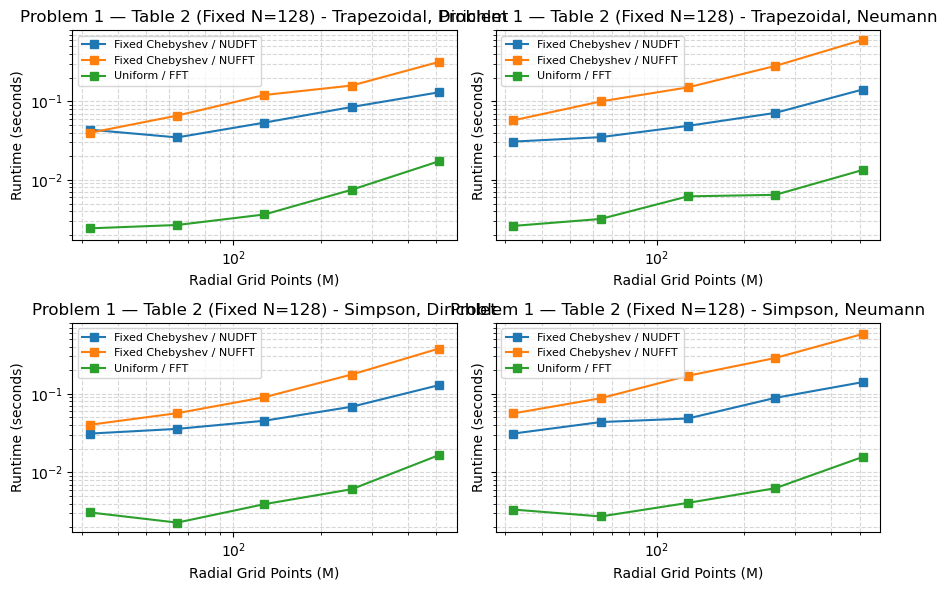


Structured Nonuniform Angular-Grid Comparison: Runtime vs. N
Varying angular resolution N; fixed radial resolution M=128

Runtime Comparison (Fixed M=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed Chebyshev Angular / NUDFT,Fixed Fibonacci (Golden Ratio) / NUDFT,Fixed Harmonic Warped / NUDFT,Fixed Multi-Pole / NUDFT,Fixed Chebyshev Angular / NUFFT,Fixed Fibonacci (Golden Ratio) / NUFFT,Fixed Harmonic Warped / NUFFT,Fixed Multi-Pole / NUFFT
N,,,,,,,,,,,
32,0.0019,0.0062,0.0297,0.0056,0.0064,0.0061,0.0053,0.1130,0.2187,0.0911,0.0902
64,0.0043,0.0091,0.0353,0.0095,0.0111,0.0121,0.0094,0.1312,0.4020,0.0257,0.0964
128,0.0053,0.0341,0.0799,0.0539,0.0537,0.0441,0.0508,0.1061,1.7649,0.0643,0.1145
256,0.0118,0.1095,0.0704,0.1446,0.1593,0.1451,0.1573,0.0819,2.7610,0.0714,0.0773
512,0.0200,0.4012,0.0796,0.5109,0.5579,0.5296,0.5330,0.0898,3.5892,0.0771,0.0750


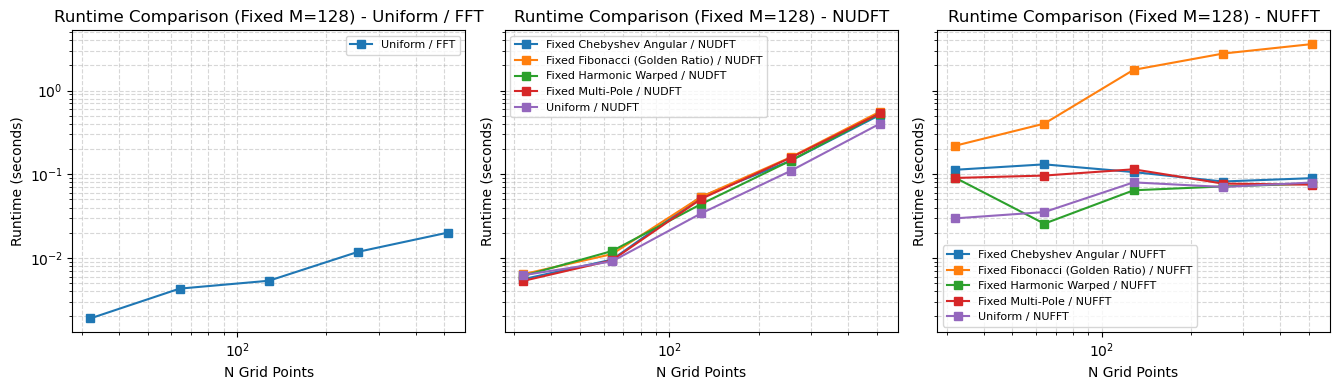


Structured Nonuniform Angular-Grid Comparison: Runtime vs. M
Varying radial resolution M; fixed angular resolution N=128

Runtime Comparison (Fixed N=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed Chebyshev Angular / NUDFT,Fixed Fibonacci (Golden Ratio) / NUDFT,Fixed Harmonic Warped / NUDFT,Fixed Multi-Pole / NUDFT,Fixed Chebyshev Angular / NUFFT,Fixed Fibonacci (Golden Ratio) / NUFFT,Fixed Harmonic Warped / NUFFT,Fixed Multi-Pole / NUFFT
M,,,,,,,,,,,
32,0.0027,0.0375,0.0291,0.0357,0.0349,0.0345,0.0342,0.0414,0.6028,0.0348,0.0475
64,0.0039,0.0364,0.0388,0.0370,0.0364,0.0376,0.0379,0.0566,0.8922,0.0395,0.0548
128,0.0073,0.0398,0.0633,0.0481,0.0478,0.0438,0.0450,0.0921,1.6170,0.0615,0.0959
256,0.0085,0.0678,0.1101,0.0763,0.0703,0.0761,0.0685,0.1573,2.9060,0.1116,0.1664
512,0.0159,0.0863,0.2115,0.1248,0.1884,0.1265,0.1106,0.3282,11.0662,0.2054,0.4442


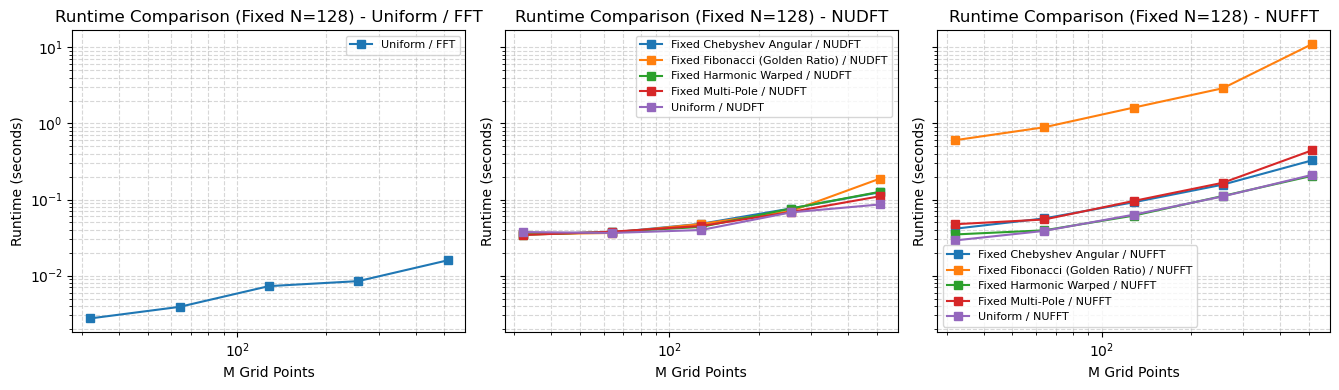

In [12]:
print("\nProblem 1 — Table 1: Runtime over angular and radial resolutions")
print("Methods: uniform FFT and fixed Chebyshev NUDFT/NUFFT")
render_runtime(
    df_p1_t1,
    index_col="N",
    columns_col=["label", "M"],
    title_prefix="Problem 1 — Table 1"
)
plot_runtime_table1(df_p1_t1, title_prefix="Problem 1 — Table 1")


print(f"\nProblem 1 — Table 2: Runtime by quadrature rule and boundary condition (N={N_fixed_p1})")
print("Methods: uniform FFT and fixed Chebyshev NUDFT/NUFFT")
render_table2_runtime(
    df_p1_t2,
    title_prefix=f"Problem 1 — Table 2 (Fixed N={N_fixed_p1})"
)
plot_runtime_table2(
    df_p1_t2,
    title_prefix=f"Problem 1 — Table 2 (Fixed N={N_fixed_p1})"
)


print("\nStructured Nonuniform Angular-Grid Comparison: Runtime vs. N")
print(f"Varying angular resolution N; fixed radial resolution M={M_fixed_c}")
render_runtime(
    df_cN,
    index_col="N",
    columns_col="label",
    title_prefix=f"Runtime Comparison (Fixed M={M_fixed_c})"
)
plot_runtime_comparison(
    df_cN,
    index_col="N",
    title_prefix=f"Runtime Comparison (Fixed M={M_fixed_c})"
)


print("\nStructured Nonuniform Angular-Grid Comparison: Runtime vs. M")
print(f"Varying radial resolution M; fixed angular resolution N={N_fixed_c}")
render_runtime(
    df_cM,
    index_col="M",
    columns_col="label",
    title_prefix=f"Runtime Comparison (Fixed N={N_fixed_c})"
)
plot_runtime_comparison(
    df_cM,
    index_col="M",
    title_prefix=f"Runtime Comparison (Fixed N={N_fixed_c})"
)